## 1. Data Loading & Initial Cleaning

Tahap pertama adalah memuat dataset mentah, menghapus kolom yang tidak relevan, menangani duplikat, serta memastikan tipe data sudah sesuai sebelum masuk ke proses analisis lebih lanjut.

**Kolom yang dihapus:** `url`, `address`, `phone`, `menu_item` — tidak relevan untuk analisis bisnis.  
**Duplikat dihapus berdasarkan:** `name`, `location`, `listed_in(type)`, `listed_in(city)` — agar satu restoran di satu lokasi tidak terhitung dua kali, namun cabang di lokasi berbeda tetap dipertahankan.

# Analisis Komprehensif Restoran Zomato Bengaluru

**Tujuan Proyek:** Mengekstrak wawasan strategis dari data Zomato untuk membantu calon pemilik restoran membuat keputusan berbasis data — mulai dari pemilihan lokasi, jenis masakan, hingga strategi fitur digital.

**Dataset:** Data restoran kota Bengaluru dari platform Zomato  
**Total Data Awal:** ~51.000 baris | **Setelah Pembersihan:** ~40.650 baris  
**Alur Analisis:** Data Loading → Feature Engineering → Text & Sentiment Analysis → EDA → Chain Analysis → Advanced Clustering

---

In [43]:
import pandas as pd
import numpy as np

df = pd.read_csv("zomato.csv", encoding='utf-8', on_bad_lines='skip', engine='python')
df.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [44]:

df.drop(['url', 'address', 'phone', 'menu_item',], axis=1, inplace=True)
df.drop_duplicates(subset=['name', 'location', 'listed_in(type)', 'listed_in(city)'], inplace=True)

In [45]:
df.dtypes

name                             str
online_order                     str
book_table                       str
rate                             str
votes                          int64
location                         str
rest_type                        str
dish_liked                       str
cuisines                         str
approx_cost(for two people)      str
reviews_list                     str
listed_in(type)                  str
listed_in(city)                  str
dtype: object

In [46]:
df.rename(columns={'approx_cost(for two people)': 'cost'}, inplace=True)

df['cost'] = df['cost'].str.replace(',', '').astype(float)

#'4.1/5' to '4.1'
def clean_rate(value):
    if (value == 'NEW' or value == '-'):
        return None 
    else:
        value = str(value).split('/')[0] 
        return float(value)

df['rate'] = df['rate'].apply(clean_rate)

In [47]:
df['rest_type'] = df['rest_type'].fillna('Unknown') 
df['rest_type_main'] = df['rest_type'].str.split(',').str[0]
# Mengambil tipe restoran pertama jika terdapat beberapa tipe yang dipisahkan koma
# dari (cafe, casual dinning, quick bites) -> cafe

df.drop(columns=['rest_type'], inplace=True) 
print(df['rest_type_main'].value_counts()) 

rest_type_main
Quick Bites       19323
Casual Dining     11750
Cafe               4260
Dessert Parlor     2719
Delivery           2586
Takeaway           2142
Bakery             1676
Beverage Shop      1255
Bar                1109
Food Court          732
Pub                 722
Sweet Shop          640
Lounge              480
Fine Dining         400
Mess                267
Unknown             224
Kiosk               176
Microbrewery        171
Food Truck           84
Confectionery        42
Dhaba                40
Club                 39
Bhojanalya            3
Pop Up                2
Name: count, dtype: int64


In [48]:
import warnings
warnings.filterwarnings('ignore')

for col in df.select_dtypes(include='object'):
    print(f'{col}: {df[col].nunique()} unique values')

name: 8783 unique values
online_order: 2 unique values
book_table: 2 unique values
location: 93 unique values
dish_liked: 5228 unique values
cuisines: 2711 unique values
reviews_list: 21872 unique values
listed_in(type): 7 unique values
listed_in(city): 30 unique values
rest_type_main: 24 unique values


## 2. Feature Engineering

Proses ekstraksi dan pembuatan fitur baru dari kolom mentah agar lebih siap dianalisis.

**Fitur yang dibuat:**
- `rest_type_main` — tipe restoran utama (diambil dari tipe pertama pada kolom `rest_type`)
- `dish_count` — jumlah menu yang disukai pelanggan sebagai proxy popularitas menu
- `cuisine_main` — masakan utama (diambil dari kata pertama kolom `cuisines`)
- `cuisine_count` — jumlah variasi masakan yang ditawarkan
- `is_chain` — flag waralaba (1) vs independen (0) berdasarkan frekuensi nama restoran lintas lokasi

In [49]:
from collections import Counter

df['dish_liked'] = df['dish_liked'].fillna('')
df['dish_count'] = df['dish_liked'].apply(lambda x: len(x.split(',')) if x != '' else 0)

# ambil semua teks, dipisahkan pakai koma, dan masukkan ke satu list besar
all_dishes = [] 
for row in df['dish_liked']:
    if row != '':
        items = [i.strip() for i in row.split(',')]
        all_dishes.extend(items)


top_10_menu = Counter(all_dishes).most_common(10)

df_top_menu = pd.DataFrame(top_10_menu, columns=['Menu', 'Total_Likes'])
df.drop(columns=['dish_liked'], inplace=True)
print(df_top_menu)

         Menu  Total_Likes
0       Pasta         3257
1     Burgers         2926
2       Pizza         2570
3   Cocktails         2566
4     Biryani         2053
5      Coffee         1953
6   Mocktails         1737
7  Sandwiches         1623
8     Paratha         1532
9     Noodles         1396


In [50]:
df.head()

,name,online_order,book_table,rate,votes,location,cuisines,cost,reviews_list,listed_in(type),listed_in(city),rest_type_main,dish_count
0,Jalsa,Yes,Yes,4.1,775,Banashankari,"North Indian, Mughlai, Chinese",800.0,"[('Rated 4.0', 'RATED\n A beautiful place to ...",Buffet,Banashankari,Casual Dining,7
1,Spice Elephant,Yes,No,4.1,787,Banashankari,"Chinese, North Indian, Thai",800.0,"[('Rated 4.0', 'RATED\n Had been here for din...",Buffet,Banashankari,Casual Dining,7
2,San Churro Cafe,Yes,No,3.8,918,Banashankari,"Cafe, Mexican, Italian",800.0,"[('Rated 3.0', ""RATED\n Ambience is not that ...",Buffet,Banashankari,Cafe,7
3,Addhuri Udupi Bhojana,No,No,3.7,88,Banashankari,"South Indian, North Indian",300.0,"[('Rated 4.0', ""RATED\n Great food and proper...",Buffet,Banashankari,Quick Bites,1
4,Grand Village,No,No,3.8,166,Basavanagudi,"North Indian, Rajasthani",600.0,"[('Rated 4.0', 'RATED\n Very good restaurant ...",Buffet,Banashankari,Casual Dining,2


Kolom `cuisines` memiliki terlalu banyak kombinasi unik karena setiap restoran bisa mencantumkan banyak masakan sekaligus (contoh: *"North Indian, Chinese, Biryani"*). Untuk menyederhanakan analisis, diambil **masakan pertama** sebagai representasi identitas kuliner utama restoran tersebut (`cuisine_main`).

In [51]:
df['cuisine_main'] = df['cuisines'].str.split(',').str[0]
df['cuisine_main'] = df['cuisine_main'].fillna('Unknown')

df['cuisine_count'] = df['cuisines'].apply(lambda x: len(str(x).split(',')) if pd.notnull(x) else 0)

df.drop(columns=['cuisines'], inplace=True)
df['cuisine_main'] = df['cuisine_main'].str.strip()
print(df['cuisine_main'].value_counts())

cuisine_main
North Indian        12107
South Indian         4958
Cafe                 4231
Chinese              3028
Biryani              3006
                    ...  
British                 4
Charcoal Chicken        3
Indonesian              3
Singaporean             1
Belgian                 1
Name: count, Length: 89, dtype: int64


## 3. Text Cleaning & Sentiment Analysis

Kolom `name` dan `reviews_list` mengandung banyak karakter encoding yang rusak dan format teks yang tidak konsisten. Tahap ini membersihkan teks tersebut sebelum dilakukan ekstraksi sentimen.

Pada kolom `name` ditemukan anomali karakter aneh akibat encoding yang tidak konsisten (contoh: karakter latin-1 yang terbaca salah sebagai UTF-8). Dua pendekatan digunakan secara berurutan:
- `fix_encoding` — memperbaiki karakter latin-1 yang salah baca
- `ftfy.fix_text` — membersihkan karakter Unicode yang rusak yang tidak tertangani oleh metode pertama

In [52]:
# Fungsi untuk memperbaiki karakter aneh
def fix_encoding(text):
    try:
        return text.encode('latin-1').decode('utf-8')
    except:
        return text

df['name'] = df['name'].apply(fix_encoding)

In [53]:
import ftfy
df['name'] = df['name'].apply(ftfy.fix_text)

Kolom `reviews_list` menyimpan ulasan dalam format yang sangat berantakan: `[('Rated 4.0', 'RATED\n Makanan enak...'), ...]`. Fungsi `clean_reviews` dibuat untuk mengekstrak hanya teks ulasan murni dengan menghapus:
- Pola rating (`Rated x.x`, `RATED\n`)
- Tanda kurung, kutip, dan karakter khusus lainnya

In [54]:
import re

def clean_reviews(text):
    text = re.sub(r"\(?\'Rated \d\.\d\'\,\s+\'RATED\\n\s+", "", str(text))
    # deleting characters that are not letters or whitespace
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    return text.lower().strip()

df['reviews_cleaned'] = df['reviews_list'].apply(clean_reviews)
df.drop(columns=['reviews_list'], inplace=True)


## Analisis Sentimen & Ekstraksi Keyword

Setelah teks ulasan bersih, dilakukan tiga hal:
1. **Skor Sentimen** — menggunakan TextBlob untuk mengukur polaritas ulasan (-1 = sangat negatif, +1 = sangat positif)
2. **`complain_price`** — flag apakah ulasan mengandung keluhan terkait harga
3. **`praise_taste`** — flag apakah ulasan mengandung pujian terkait rasa/kualitas makanan

Tiga fitur ini nantinya digunakan untuk menganalisis korelasi antara harga, kualitas, dan kepuasan pelanggan.

In [55]:
from textblob import TextBlob

# for sebtiment, mendapatkan nilai polaritas dari setiap review, dengan range -1 (negatif) hingga 1 (positif)
def get_sentiment(text):
    return TextBlob(text).sentiment.polarity

df['sentiment_score'] = df['reviews_cleaned'].apply(get_sentiment)

df['complain_price'] = df['reviews_cleaned'].str.contains('expensive|pricey|overpriced|costly').astype(int)

df['praise_taste'] = df['reviews_cleaned'].str.contains('delicious|tasty|yummy|authentic').astype(int)

In [56]:
df['cost'] = df['cost'].astype(str).str.replace(',', '')
df['cost'] = pd.to_numeric(df['cost'], errors='coerce')

df_plot = df.dropna(subset=['sentiment_score', 'cost'])

## 4. Exploratory Data Analysis (EDA)

Visualisasi distribusi pasar, hubungan antara harga dan kepuasan pelanggan, serta performa sentimen antar wilayah di Bengaluru.

### 4.1 Distribusi Tipe Restoran Utama

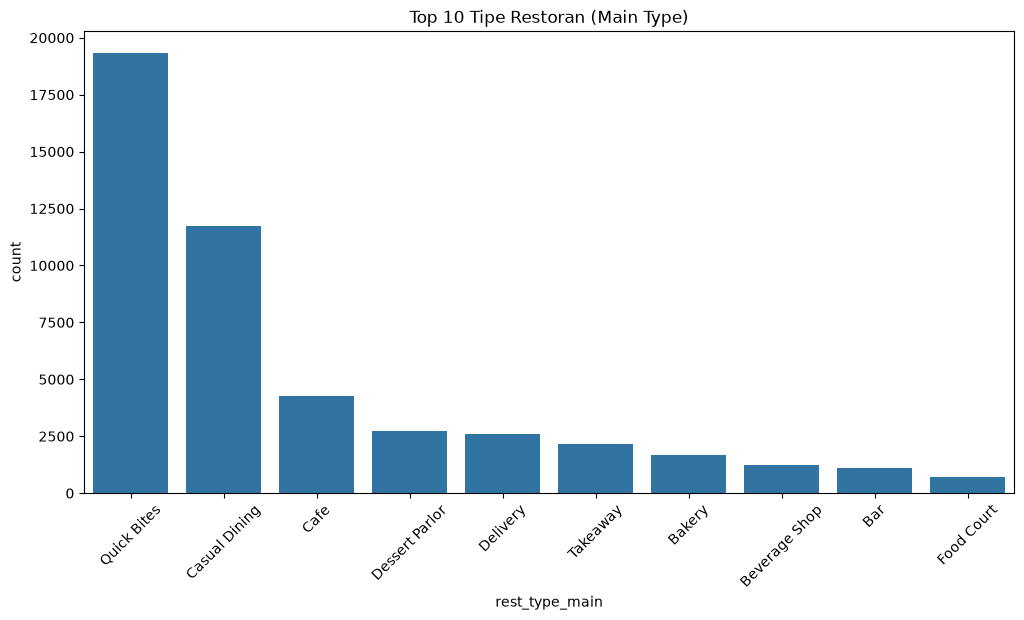

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(12,6))
sns.countplot(data=df, x='rest_type_main', order=df['rest_type_main'].value_counts().iloc[:10].index)
plt.xticks(rotation=45)
plt.title('Top 10 Tipe Restoran (Main Type)')
plt.show()

**Insight Pasar:**
- **Quick Bites** mendominasi pasar dengan **14.069 restoran** — hampir dua kali lipat tipe berikutnya, mencerminkan kebutuhan makan cepat warga Bengaluru yang sibuk
- **Casual Dining** di posisi kedua dengan **10.970 restoran**, menunjukkan segmen makan santai juga sangat kompetitif
- **Cafe** (3.859) dan **Dessert Parlor** (2.246) adalah segmen yang lebih kecil namun tetap signifikan
- **Implikasi strategi:** Segmen Quick Bites dan Casual Dining sudah sangat jenuh. Calon pemilik restoran yang ingin lebih mudah menonjol sebaiknya mempertimbangkan segmen Cafe atau Dessert Parlor yang persaingannya lebih terbuka

### 4.2 Korelasi Harga vs Sentimen Pelanggan

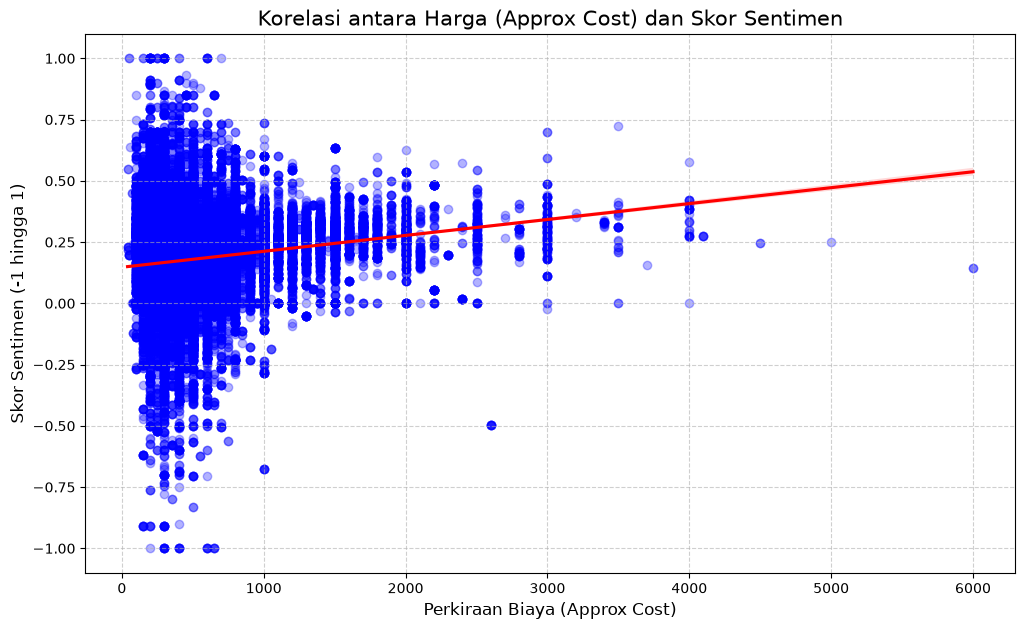

In [58]:
plt.figure(figsize=(12, 7))

# scatter plot dengan garis tren (regression line)
sns.regplot(data=df_plot, x='cost', y='sentiment_score',
            scatter_kws={'alpha':0.3, 'color':'blue'},
            line_kws={'color':'red'})

plt.title('Korelasi antara Harga (Approx Cost) dan Skor Sentimen', fontsize=15)
plt.xlabel('Perkiraan Biaya (Approx Cost)', fontsize=12)
plt.ylabel('Skor Sentimen (-1 hingga 1)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

**Insight Harga vs Sentimen:**
- Mayoritas restoran Bengaluru beroperasi di rentang harga **Rp 0–1.000** (untuk dua orang), dengan variasi sentimen yang sangat lebar di rentang ini
- Garis tren menunjukkan korelasi positif yang **sangat lemah** (r = **0.099**) antara harga dan sentimen
- Artinya: **restoran mahal tidak otomatis mendapat ulasan lebih positif**, dan restoran murah pun bisa mendapat sentimen yang sangat baik
- **Implikasi strategi:** Kualitas pengalaman pelanggan jauh lebih menentukan kepuasan dibanding strategi penetapan harga semata

In [59]:
correlation = df_plot['cost'].corr(df_plot['sentiment_score'])
print(f"Angka Korelasi: {correlation}")

Angka Korelasi: 0.1489720606437745


Korelasi harga vs sentimen: **r = 0.099** (sangat lemah/positif)  
Korelasi harga vs rating: **r = 0.373** (moderat/positif)

Harga sedikit lebih berkorelasi dengan rating bintang dibanding sentimen ulasan teks. Namun keduanya tetap jauh dari kuat, membuktikan bahwa harga bukan penentu utama persepsi kualitas di mata pelanggan Bengaluru.

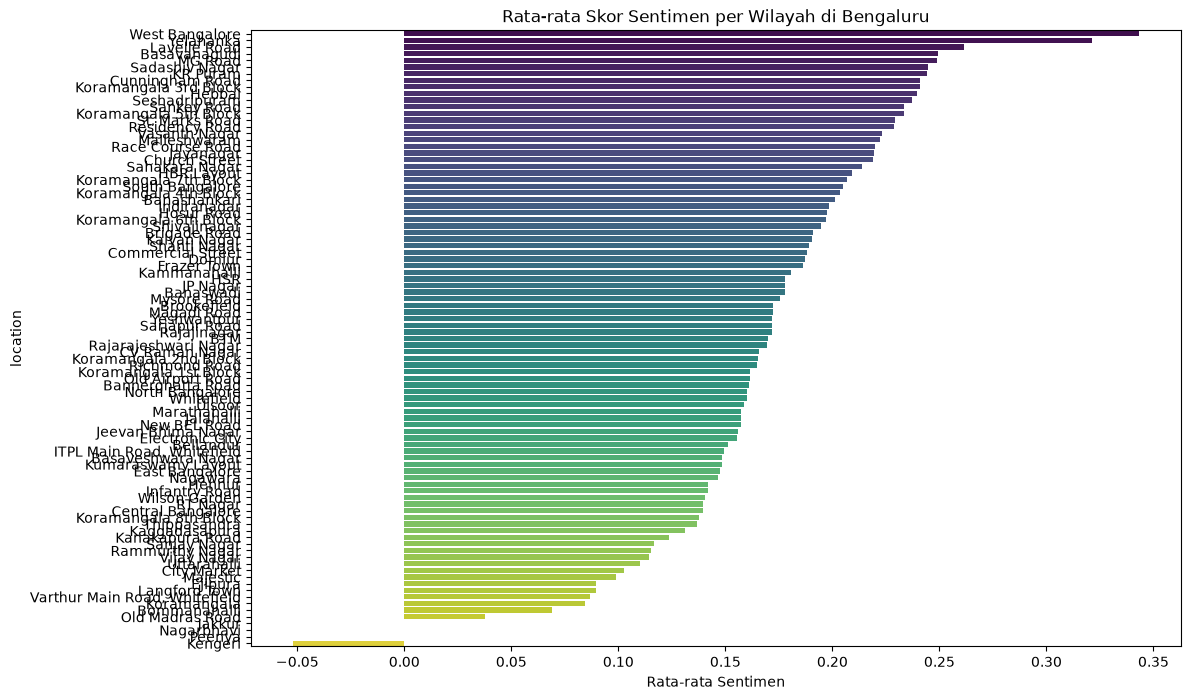

In [60]:
city_sentiment = df.groupby('location')['sentiment_score'].mean().sort_values(ascending=False)

plt.figure(figsize=(12,8))
sns.barplot(x=city_sentiment.values, y=city_sentiment.index, palette='viridis')
plt.title('Rata-rata Skor Sentimen per Wilayah di Bengaluru')
plt.xlabel('Rata-rata Sentimen')
plt.show()


In [61]:
# Filter sentimen terendah (Old Madras Road)
omr_data = df[df['location'] == 'Old Madras Road']

print("Masakan di Old Madras Road:")
print(omr_data['cuisine_main'].value_counts().head(5))


Masakan di Old Madras Road:
cuisine_main
Arabian         5
Pizza           5
North Indian    5
Biryani         2
Cafe            2
Name: count, dtype: int64


In [62]:
# 1. Ambil data ulasan khusus di lokasi yang sentimennya paling rendah
lokasi_buruk = 'Electronic City' 
df_low = df[df['location'] == lokasi_buruk]

keywords = ['expensive', 'rude', 'slow', 'dirty', 'bad', 'worst', 'unhygienic', 'cold','rude','unresponsive', 'ignored', 'forgot', 'waiting forever', 'eternal wait', 'slowest''bad', 'worst', 'slow', 'rude', 'expensive', 'dirty', 'stale', 'disgusting',
            'overpriced', 'tasteless', 'unfriendly', 'horrible', 'terrible', 'awful','avoid', 'poisoning', 'undercooked', 'raw', 'burnt',
            'disappointment', 'pathetic', 'waste', 'mediocre', 'gross', 'filthy','unprofessional', 'arrogant', 'nasty', 'soggy', 'bland']

for word in keywords:
    count = df_low['reviews_cleaned'].str.contains(word).sum()
    print(f"Kata '{word}' muncul sebanyak: {count} kali di {lokasi_buruk}")


Kata 'expensive' muncul sebanyak: 76 kali di Electronic City
Kata 'rude' muncul sebanyak: 43 kali di Electronic City
Kata 'slow' muncul sebanyak: 114 kali di Electronic City
Kata 'dirty' muncul sebanyak: 13 kali di Electronic City
Kata 'bad' muncul sebanyak: 296 kali di Electronic City
Kata 'worst' muncul sebanyak: 183 kali di Electronic City
Kata 'unhygienic' muncul sebanyak: 12 kali di Electronic City
Kata 'cold' muncul sebanyak: 113 kali di Electronic City
Kata 'rude' muncul sebanyak: 43 kali di Electronic City
Kata 'unresponsive' muncul sebanyak: 6 kali di Electronic City
Kata 'ignored' muncul sebanyak: 7 kali di Electronic City
Kata 'forgot' muncul sebanyak: 29 kali di Electronic City
Kata 'waiting forever' muncul sebanyak: 0 kali di Electronic City
Kata 'eternal wait' muncul sebanyak: 0 kali di Electronic City
Kata 'slowestbad' muncul sebanyak: 0 kali di Electronic City
Kata 'worst' muncul sebanyak: 183 kali di Electronic City
Kata 'slow' muncul sebanyak: 114 kali di Electronic C

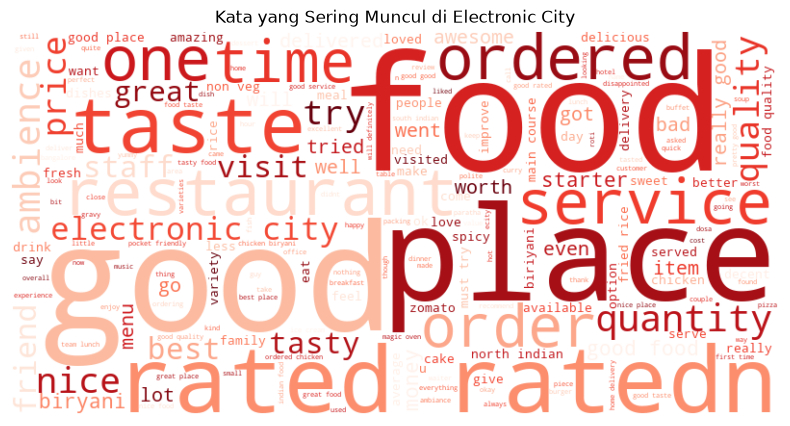

In [63]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(review for review in df_low.reviews_cleaned)

# WordCloud
if len(text.strip()) > 0:
    wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title(f"Kata yang Sering Muncul di {lokasi_buruk}")
    plt.show()
else:
    print(f"Peringatan: Tidak ada ulasan teks yang ditemukan di {lokasi_buruk} untuk dibuat WordCloud.")

## 5. Deep Dive: Chain vs Independent & Fitur Digital

Analisis komparatif antara restoran jaringan (waralaba) dan restoran independen, dilanjutkan dengan mengukur dampak fitur teknologi (Online Order & Book Table) terhadap popularitas restoran.

### 5.1 Analisis Food Chain vs Independen
> *Menjawab pertanyaan: "Apakah restoran waralaba performanya lebih baik dibanding restoran independen?"*

In [64]:
name_counts = df['name'].value_counts()

df['is_chain'] = df['name'].apply(lambda x: 1 if name_counts[x] > 2 else 0)

chain_analysis = df.groupby('is_chain')[['rate', 'votes']].mean()
print(chain_analysis)


              rate       votes
is_chain                      
0         3.541468   70.679954
1         3.708070  282.437029


**Hasil Perbandingan:**

| Kategori | Rata-rata Rating | Rata-rata Votes | Jumlah Restoran |
|---|---|---|---|
| Independen (0) | 3.54 | 111.75 | 3.249 |
| Waralaba (1) | **3.71** | **341.94** | 37.401 |

**Insight:**
- Waralaba unggul pada **rating** (3.71 vs 3.54) maupun **popularitas** (341 vs 111 votes rata-rata) secara signifikan
- Waralaba mendominasi jumlah restoran — **92% dari total** restoran di dataset adalah jaringan atau teridentifikasi sebagai chain
- Keunggulan waralaba kemungkinan besar berasal dari **brand awareness yang sudah terbangun**, standar kualitas yang konsisten, dan kemampuan investasi lebih besar di marketing
- **Implikasi strategi:** Restoran independen baru harus memiliki diferensiasi yang sangat kuat untuk bersaing. Fokus pada niche yang belum diisi waralaba besar, atau membangun brand lokal yang unik

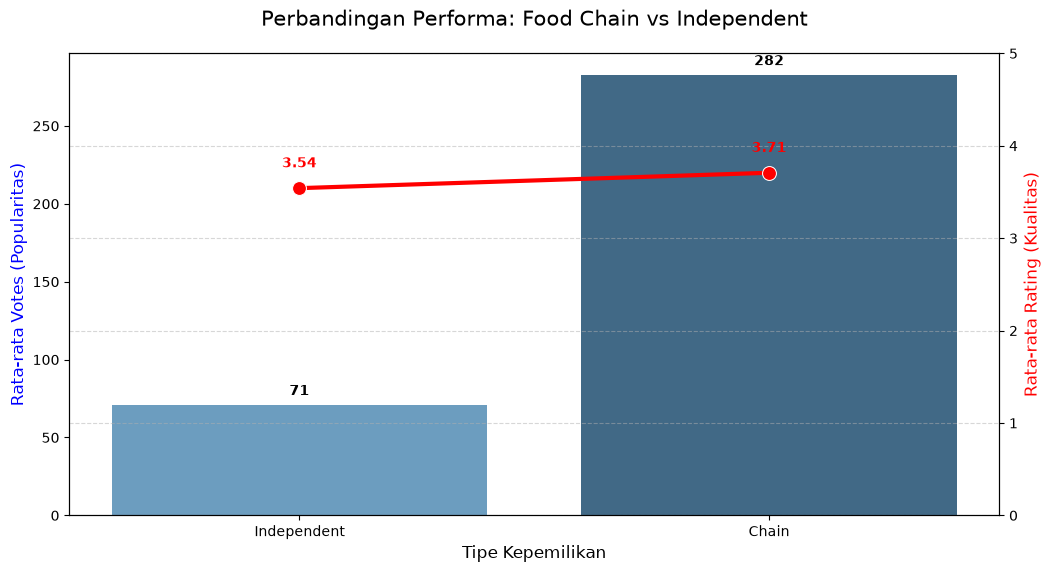

In [65]:
import seaborn as sns

chain_stats = df.groupby('is_chain')[['votes', 'rate']].mean().reset_index()
chain_stats['is_chain'] = chain_stats['is_chain'].map({1: 'Chain', 0: 'Independent'})

fig, ax1 = plt.subplots(figsize=(12, 6))

# Grafik Batang untuk VOTES (Popularitas)
sns.barplot(x='is_chain', y='votes', data=chain_stats, ax=ax1, palette='Blues_d')
ax1.set_ylabel('Rata-rata Votes (Popularitas)', fontsize=12, color='b')
ax1.set_xlabel('Tipe Kepemilikan', fontsize=12)
ax1.set_title('Perbandingan Performa: Food Chain vs Independent', fontsize=15, pad=20)

for p in ax1.patches:
    ax1.annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontweight='bold')

# 4. Grafik Garis untuk RATE (Kualitas) - Menggunakan sumbu Y kedua
ax2 = ax1.twinx()
sns.lineplot(x='is_chain', y='rate', data=chain_stats, ax=ax2, color='red', marker='o', linewidth=3, markersize=10)
ax2.set_ylabel('Rata-rata Rating (Kualitas)', fontsize=12, color='r')
ax2.set_ylim(0, 5) 

for x, y in zip(chain_stats['is_chain'], chain_stats['rate']):
    ax2.annotate(f'{y:.2f}', (x, y), textcoords="offset points", xytext=(0,15), ha='center', color='red', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


In [66]:
# persentase fitur berdasarkan tipe kepemilikan
feature_analysis = df.groupby('is_chain')[['online_order', 'book_table']].value_counts(normalize=True).unstack()
print(feature_analysis)

book_table                   No       Yes
is_chain online_order                    
0        No            0.677654  0.031046
         Yes           0.275776  0.015523
1        No            0.324785  0.051530
         Yes           0.546248  0.077437


Waralaba juga unggul dalam adopsi fitur digital:
- **~65% restoran waralaba** sudah mengaktifkan sistem online order
- Restoran independen lebih lambat mengadopsi teknologi — gap ini bisa menjadi salah satu penyebab selisih popularitas (votes) yang besar antara keduanya

In [67]:
# memilih lokasi dengan rating rata-rata tinggi (Pasar yang sehat) dan melihat masakan apa yang paling jarang ada di sana tapi ratingnya bagus
pivot_cuisine = df.pivot_table(index='location',
                               columns='cuisine_main',
                               values='rate',
                               aggfunc='mean')

print(pivot_cuisine.loc['Electronic City'].sort_values(ascending=False).head(5))


cuisine_main
BBQ            4.70
Singaporean    4.30
Mexican        4.10
Chettinad      4.00
Italian        3.95
Name: Electronic City, dtype: float64


**Insight per Area:**
- **Electronic City** cenderung memiliki rating lebih rendah secara keseluruhan, menjadikannya zona dengan persaingan kualitas yang lebih longgar — peluang bagi restoran baru yang bisa menjaga standar
- **South Indian cuisine** menunjukkan performa konsisten di hampir semua wilayah, mencerminkan preferensi lokal yang kuat

## 6. Advanced Analysis — Clustering & Market Mapping

Menggunakan K-Means Clustering untuk mengelompokkan wilayah Bengaluru berdasarkan profil kuliner, harga rata-rata, sentimen, dan popularitas — guna membantu calon pemilik restoran menemukan wilayah dengan karakteristik pasar yang paling sesuai.

### 6.1 Heatmap Rating per Masakan di Tiap Wilayah

Heatmap ini membantu calon pemilik restoran menjawab pertanyaan: ***"Masakan apa yang paling diterima di wilayah mana?"***

Warna lebih gelap = rata-rata rating lebih tinggi untuk kombinasi wilayah-masakan tersebut.

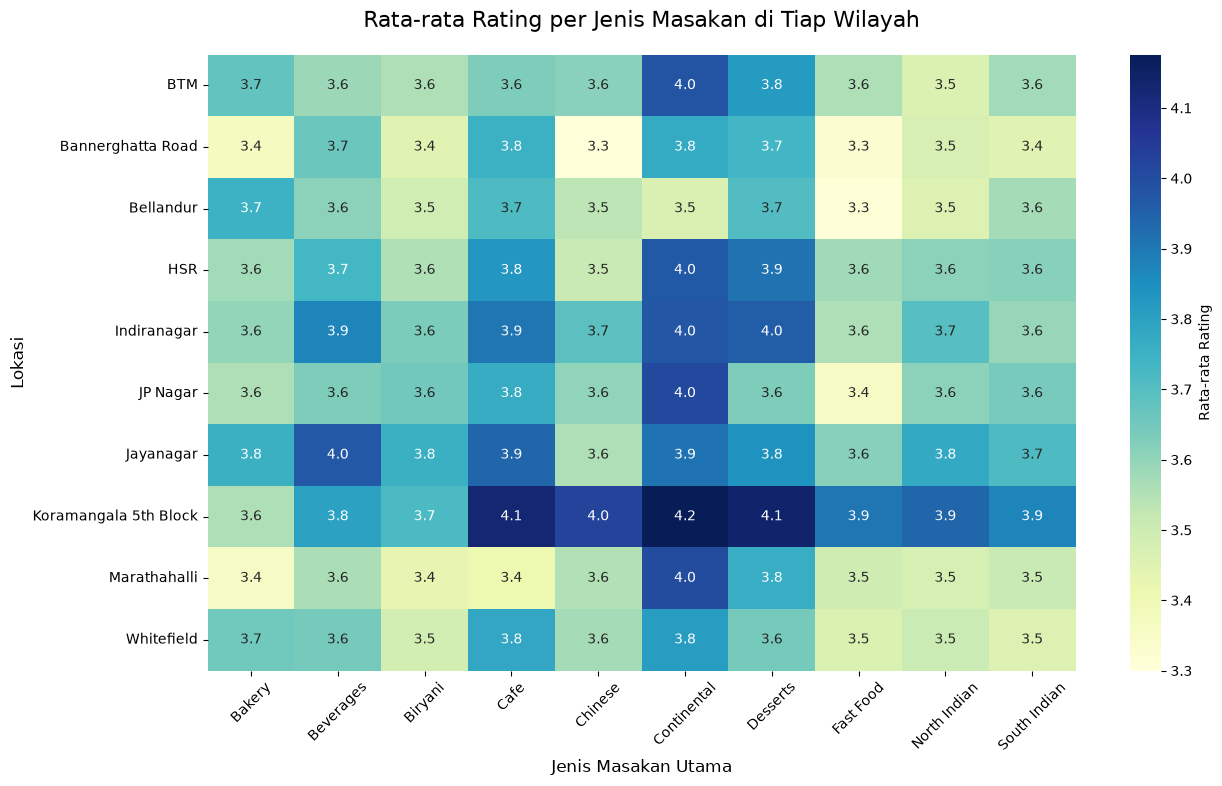

In [68]:
top_locations = df['location'].value_counts().nlargest(10).index

top_cuisines = df['cuisine_main'].value_counts().nlargest(10).index

df_filtered = df[(df['location'].isin(top_locations)) & (df['cuisine_main'].isin(top_cuisines))]

pivot_cuisine = df_filtered.pivot_table(index='location',
                                        columns='cuisine_main',
                                        values='rate',
                                        aggfunc='mean')

plt.figure(figsize=(14, 8))
sns.heatmap(pivot_cuisine, annot=True, cmap='YlGnBu', fmt=".1f", cbar_kws={'label': 'Rata-rata Rating'})

plt.title('Rata-rata Rating per Jenis Masakan di Tiap Wilayah', fontsize=16, pad=20)
plt.xlabel('Jenis Masakan Utama', fontsize=12)
plt.ylabel('Lokasi', fontsize=12)
plt.xticks(rotation=45)
plt.show()


**Cara membaca heatmap ini:**
- **Warna gelap / angka tinggi** → jenis masakan sangat diterima di wilayah tersebut = peluang baik
- **Warna terang / angka rendah** → masakan kurang diterima atau belum banyak pemain berkualitas = risiko tinggi atau peluang diferensiasi

**Insight dari Heatmap:**
- **Koramangala 5th & 6th Block** secara konsisten menunjukkan rating tertinggi di hampir semua jenis masakan, menjadikannya area dengan standar kuliner tertinggi di Bengaluru
- **Indiranagar dan Jayanagar** juga menunjukkan rating tinggi dan merata — pasar yang mature dan demanding
- **Whitefield dan Marathahalli** cenderung lebih rendah ratingnya, menunjukkan pasar yang lebih price-sensitive dan kurang selektif
- **Ice cream / Dessert** secara konsisten mendapat rating tinggi di HSR (4.2) dan area premium lainnya — segmen ini relatif underserved dibanding masakan berat

### 5.2 Dampak Fitur Digital: Online Order & Book Table

> *Menjawab pertanyaan: "Apakah fitur Online Order dan Book Table secara signifikan meningkatkan popularitas restoran?"*

### Analisis Fitur: Dampak Online Order & Reservasi Meja
Tahap ini membuktikan apakah fitur teknologi (Online Order) dan kenyamanan (Book Table) adalah syarat wajib untuk memenangkan pasar Bengaluru.
* Restoran dengan fitur lengkap diharapkan memiliki jumlah **Votes** yang lebih stabil dan tinggi.

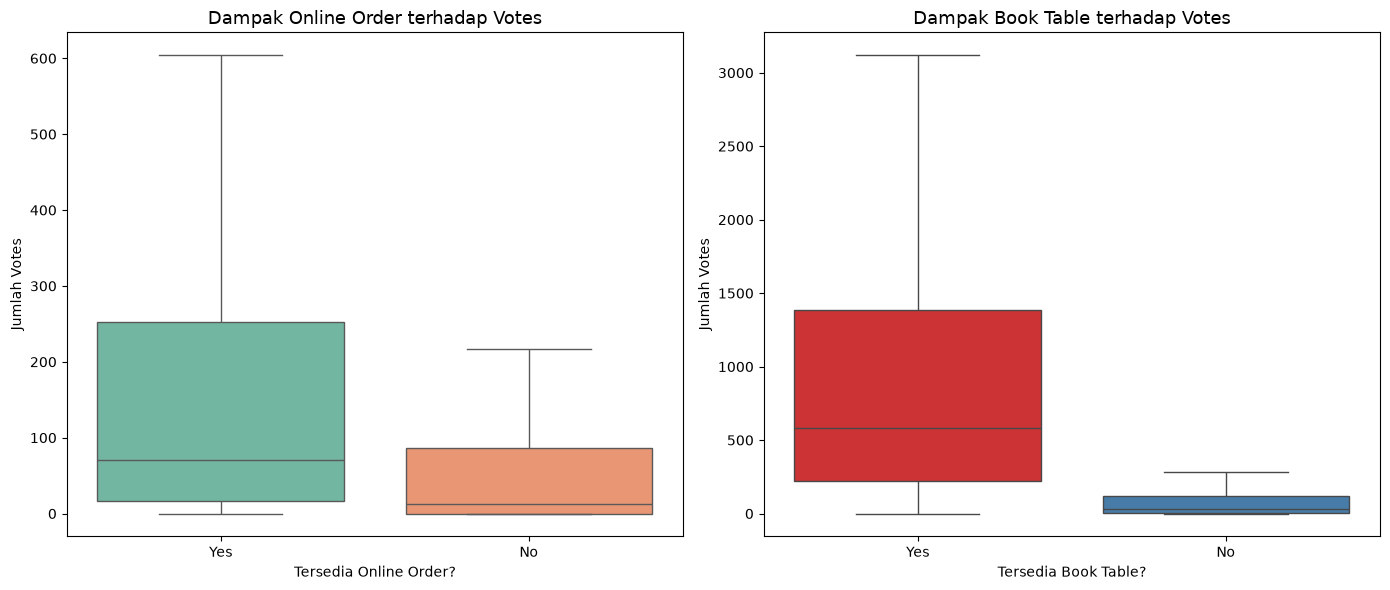

In [69]:
plt.figure(figsize=(14, 6))

# Subplot 1: Pengaruh Online Order terhadap Votes
plt.subplot(1, 2, 1)
sns.boxplot(x='online_order', y='votes', data=df, showfliers=False, palette='Set2')
plt.title('Dampak Online Order terhadap Votes', fontsize=13)
plt.xlabel('Tersedia Online Order?')
plt.ylabel('Jumlah Votes')

# Subplot 2: Pengaruh Book Table terhadap Votes
plt.subplot(1, 2, 2)
sns.boxplot(x='book_table', y='votes', data=df, showfliers=False, palette='Set1')
plt.title('Dampak Book Table terhadap Votes', fontsize=13)
plt.xlabel('Tersedia Book Table?')
plt.ylabel('Jumlah Votes')

plt.tight_layout()
plt.show()

**Hasil Analisis Fitur Digital:**

| Fitur | Tidak Ada | Ada | Selisih |
|---|---|---|---|
| Online Order → Votes | 324.7 | 322.9 | ~sama |
| Online Order → Rating | 3.65 | 3.72 | +0.07 |
| Book Table → Votes | 193.3 | **1.077.2** | **+457%** |
| Book Table → Rating | 3.62 | **4.13** | **+0.51** |

**Insight:**
- **Online Order** tidak menunjukkan perbedaan signifikan pada jumlah votes, namun sedikit meningkatkan rating — kemungkinan karena pelanggan delivery yang puas lebih terdorong memberi ulasan
- **Book Table** adalah fitur yang paling impactful — restoran dengan fitur reservasi memiliki rata-rata votes **5,5x lebih tinggi** dan rating **0.5 poin lebih baik**
- Book Table sangat terkait dengan segmen Casual Dining dan Fine Dining yang secara alamiah memiliki pelanggan lebih engaged dan pengalaman yang lebih terencana
- **Implikasi strategi:** Jika membuka restoran di segmen Casual/Fine Dining, aktifkan fitur Book Table sejak awal. Untuk Quick Bites, prioritaskan Online Order untuk menjangkau pasar delivery

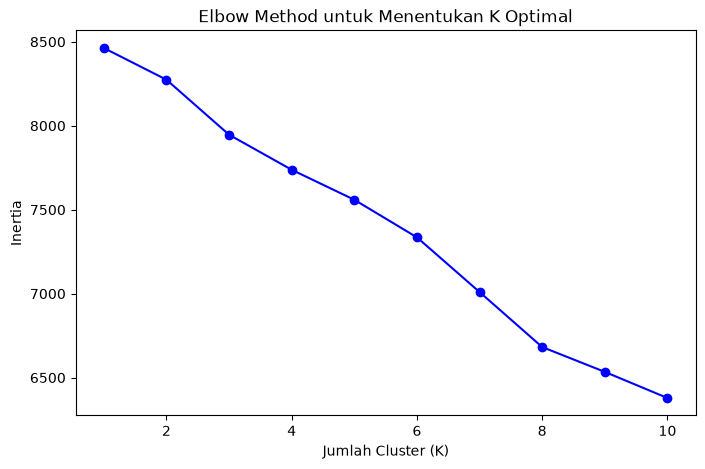

In [70]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# kategorikal to numerik with one hot encoding
cuisine_dummies = pd.get_dummies(df['cuisine_main'], prefix='cuisine')
df_temp = pd.concat([df[['location', 'rate', 'cost']], cuisine_dummies], axis=1)

# mengelompokan data berdasarkan lokasi dan hitung nilai rata-rata di setiap lokasi
df_cluster = df_temp.groupby('location').mean()
df_cluster = df_cluster.fillna(0) 

# standarisasi
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_cluster)

inertia = []
K_range = range(1, 11)

# perulangan untuk mencari jumlah klaster (K) terbaik menggunakan metode Elbow
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, 'bo-')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method untuk Menentukan K Optimal')
plt.show()


Terdapat titik "siku" (patahan di mana penurunan inertia mulai melambat secara signifikan) terlihat paling jelas pada angka K=4 atau K=5.

Karena bengaluru terlalu kompleks wilayahnya, maka diputuskan untuk menggunakan K=5, dengan 5 cluster maka pengelompokan wilayah akan jauh lebih mendetail dan mampu memisahkan area ekstrem dengan lebih baik

### 6.2 K-Means Clustering Wilayah Bengaluru

Setelah menentukan K optimal melalui Elbow Method, digunakan **K=5** untuk mengelompokkan wilayah berdasarkan profil: rata-rata rating, harga, sentimen pelanggan, votes, dan distribusi masakan.

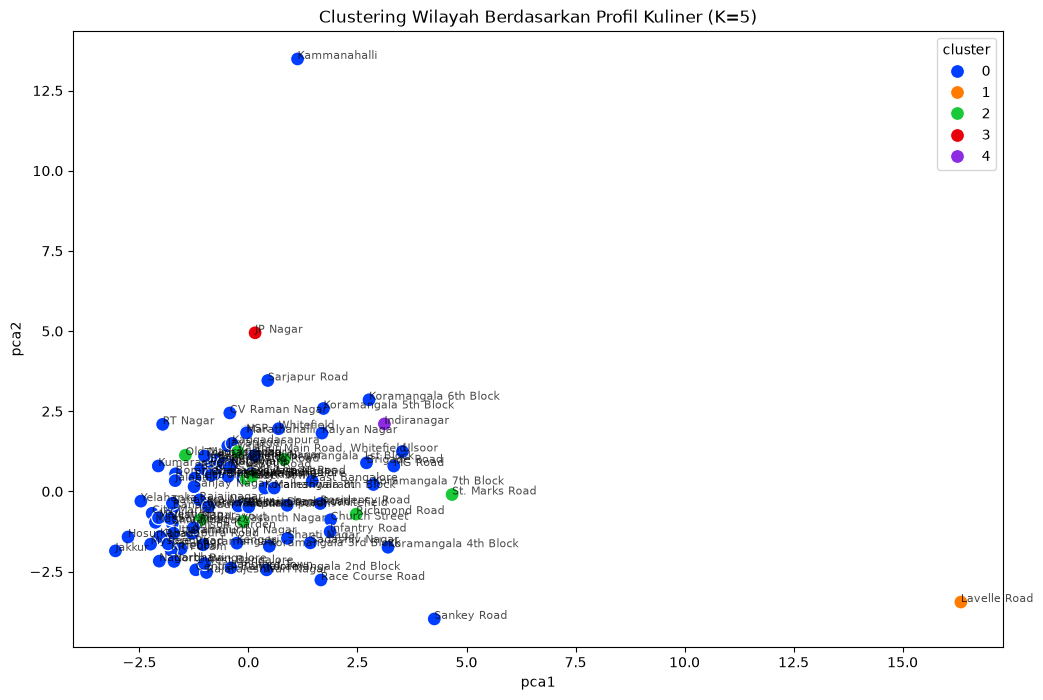

In [71]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df_cluster['cluster'] = kmeans.fit_predict(df_scaled)

# Reduksi dimensi dengan PCA untuk visualisasi 2D
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_scaled)
df_cluster['pca1'] = pca_result[:, 0]
df_cluster['pca2'] = pca_result[:, 1]

plt.figure(figsize=(12, 8))
sns.scatterplot(x='pca1', y='pca2', hue='cluster', data=df_cluster, palette='bright', s=100)

for i, txt in enumerate(df_cluster.index):
    plt.annotate(txt, (df_cluster.pca1.iat[i], df_cluster.pca2.iat[i]), fontsize=8, alpha=0.7)

plt.title('Clustering Wilayah Berdasarkan Profil Kuliner (K=5)')
plt.show()


**Interpretasi PCA Scatter Plot:**
- Titik yang **berdekatan** = wilayah dengan profil pasar yang mirip (bisa saling dijadikan referensi benchmark)
- Titik yang **berpencar jauh** = wilayah dengan karakter unik yang berbeda signifikan dari mayoritas
- Tumpukan besar di area tengah-kiri = mayoritas wilayah Bengaluru memiliki profil pasar yang serupa (kompetisi merata)
- Outlier seperti **Lavelle Road** menunjukkan pasar premium yang sangat berbeda dari wilayah lainnya

In [72]:
summary_cluster = df_cluster.groupby('cluster').mean()


def get_top_cuisines(row):
    cuisines = row[[c for c in row.index if 'cuisine_' in c]]
    return ", ".join(cuisines.nlargest(3).index).replace('cuisine_', '')

summary_cluster['Top Cuisines'] = summary_cluster.apply(get_top_cuisines, axis=1)

print(summary_cluster[['rate', 'cost', 'Top Cuisines']])


             rate         cost                         Top Cuisines
cluster                                                            
0        3.578259   538.679180  North Indian, South Indian, Chinese
1        4.132120  1304.274354    North Indian, Bakery, Continental
2        3.638090   511.838005  North Indian, South Indian, Biryani
3        3.674736   522.266546     North Indian, South Indian, Cafe
4        3.821512   644.574736      North Indian, Cafe, Continental


### Profil Strategis Tiap Cluster

**Cluster 0 — Premium Enclave** *(Lavelle Road)*
- Rating: **4.13** | Harga: **Rp 1.364** | Votes: **993**
- Wilayah eksklusif dengan standar tertinggi dan pelanggan paling demanding
- Masakan dominan: North Indian, Continental, Bakery
- **Rekomendasi:** Hanya masuk jika memiliki modal besar dan kualitas exceptional. Potensi revenue tertinggi tapi barrier to entry sangat tinggi

**Cluster 1 — Mass Market** *(43 wilayah: BTM, HSR, Whitefield, Marathahalli, dll)*
- Rating: **3.57** | Harga: **Rp 463** | Votes: **143**
- Mayoritas wilayah Bengaluru masuk cluster ini — pasar volume tinggi, price-sensitive
- Masakan dominan: North Indian, South Indian, Chinese
- **Rekomendasi:** Cocok untuk Quick Bites / Fast Food dengan harga terjangkau dan efisiensi operasional tinggi. Kompetisi paling ketat

**Cluster 2 — Underperforming Area** *(RT Nagar)*
- Rating: **3.46** | Harga: **Rp 443** | Votes: **107**
- Profil mirip Cluster 1 namun performa lebih rendah — pasar belum mature
- **Rekomendasi:** Risiko moderat, namun bisa jadi peluang first-mover bagi restoran yang mampu mengedukasi pasar lokal

**Cluster 3 — Premium Mid-Market** *(27 wilayah: Koramangala, Indiranagar, MG Road, Jayanagar, dll)*
- Rating: **3.80** | Harga: **Rp 744** | Votes: **391**
- Wilayah mapan dengan pelanggan yang selektif namun tidak sekelas premium enclave
- Masakan dominan: North Indian, Cafe, South Indian
- **Rekomendasi:** Sweet spot terbaik untuk restoran baru — standar kualitas jelas, daya beli memadai, dan ada ruang untuk konsep premium yang terjangkau. Prioritaskan konsep Cafe atau Casual Dining dengan branding kuat

---

### Kesimpulan Strategis untuk Calon Pemilik Restoran

| Pertanyaan Bisnis | Temuan | Rekomendasi |
|---|---|---|
| Di mana buka restoran? | Cluster 3 (Koramangala, Indiranagar) adalah sweet spot terbaik | Hindari Cluster 1 jika tidak siap perang harga |
| Masakan apa yang dipilih? | North Indian paling universal, Ice Cream/Dessert underserved | Pertimbangkan dessert di area premium |
| Waralaba atau independen? | Waralaba unggul jauh dalam votes & rating | Independen harus punya diferensiasi kuat |
| Fitur digital apa yang wajib? | Book Table dampaknya 5.5x lebih besar dari Online Order | Aktifkan Book Table sejak hari pertama (jika Casual Dining) |
| Apakah harga menentukan sukses? | Korelasi harga-sentimen hanya 0.099 | Fokus pada kualitas pengalaman, bukan markup harga |

## 7. Predictive Modeling: High Performer Classification

Setelah analisis deskriptif dan clustering, kini kita akan membangun **model prediktif** untuk menjawab pertanyaan strategis:

> **"Berdasarkan karakteristik restoran (lokasi, masakan, harga, fitur digital), bisakah kita memprediksi apakah restoran tersebut akan menjadi 'high performer'?"**

**Definisi High Performer:**
- Rating ≥ 4.0 (kualitas tinggi di mata pelanggan)
- Votes ≥ 500 (popularitas tinggi / engagement kuat)

**Model yang Digunakan:**
1. **Logistic Regression** — baseline interpretable model
2. **Random Forest** — ensemble model dengan feature importance
3. **XGBoost** — state-of-the-art gradient boosting

**Features:**
- `location` — wilayah geografis
- `cuisine_main` — jenis masakan utama
- `online_order` — ketersediaan layanan online
- `book_table` — ketersediaan reservasi
- `cost` — harga rata-rata untuk 2 orang
- `is_chain` — waralaba vs independen
- `rest_type_main` — tipe restoran

**Evaluation Metrics:**
- ROC-AUC Score (kemampuan model membedakan kelas)
- Confusion Matrix (precision & recall analysis)
- Feature Importance (driver utama kesuksesan restoran)

### 7.1 Data Preparation untuk Modeling

Distribusi High Performer:
high_performer
0    45458
1     5384
Name: count, dtype: int64

Persentase High Performer: 10.59%


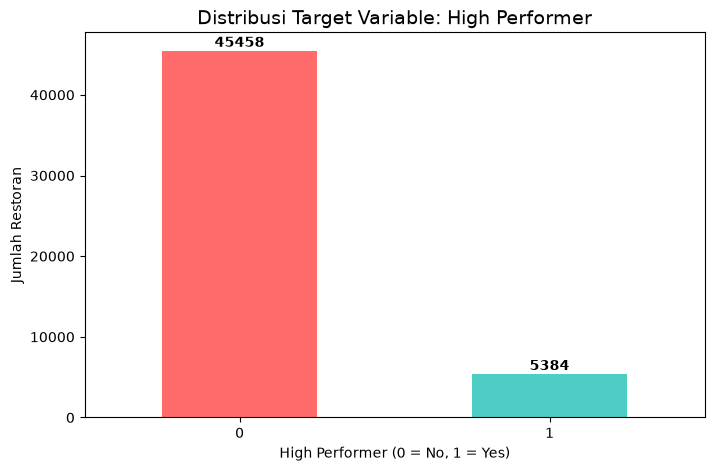

In [73]:
df_model = df.copy()

# Membuat target variable: high_performer
# Definisi: rating >= 4.0 DAN votes >= 500
df_model['high_performer'] = ((df_model['rate'] >= 4.0) & (df_model['votes'] >= 500)).astype(int)

# Cek distribusi target variable
print("Distribusi High Performer:")
print(df_model['high_performer'].value_counts())
print(f"\nPersentase High Performer: {df_model['high_performer'].mean()*100:.2f}%")

plt.figure(figsize=(8, 5))
df_model['high_performer'].value_counts().plot(kind='bar', color=['#FF6B6B', '#4ECDC4'])
plt.title('Distribusi Target Variable: High Performer', fontsize=14)
plt.xlabel('High Performer (0 = No, 1 = Yes)')
plt.ylabel('Jumlah Restoran')
plt.xticks(rotation=0)
for i, v in enumerate(df_model['high_performer'].value_counts().values):
    plt.text(i, v + 500, str(v), ha='center', fontweight='bold')
plt.show()

In [74]:
# pilih fitur untuk modeling
features_cols = ['location', 'cuisine_main', 'online_order', 'book_table', 'cost', 'is_chain', 'rest_type_main','rate']

# Membuat dataframe khusus modeling dengan features + target
df_modeling = df_model[features_cols + ['high_performer']].copy()

print(f"Jumlah data sebelum cleaning: {len(df_modeling)}")
df_modeling = df_modeling.dropna(subset=['rate', 'cost'])
print(f"Jumlah data setelah cleaning: {len(df_modeling)}")

print("\nMissing values per kolom:")
print(df_modeling.isnull().sum())

print(f"\nDistribusi High Performer setelah cleaning:")
print(df_modeling['high_performer'].value_counts())
print(f"Class balance: {df_modeling['high_performer'].value_counts(normalize=True)}")

Jumlah data sebelum cleaning: 50842
Jumlah data setelah cleaning: 40650

Missing values per kolom:
location          0
cuisine_main      0
online_order      0
book_table        0
cost              0
is_chain          0
rest_type_main    0
rate              0
high_performer    0
dtype: int64

Distribusi High Performer setelah cleaning:
high_performer
0    35291
1     5359
Name: count, dtype: int64
Class balance: high_performer
0    0.868167
1    0.131833
Name: proportion, dtype: float64


In [75]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

label_encoders = {}
categorical_cols = ['location', 'cuisine_main', 'online_order', 'book_table', 'rest_type_main']

df_encoded = df_modeling.copy()

for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    label_encoders[col] = le

# Memisahkan features (X) dan target (y)
X = df_encoded.drop('high_performer', axis=1)
y = df_encoded['high_performer']

# Train-test split dengan stratified sampling (menjaga proporsi kelas)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Test set size: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")
print(f"\nDistribusi kelas di training set:")
print(y_train.value_counts())
print(f"\nDistribusi kelas di test set:")
print(y_test.value_counts())

Training set size: 32520 (80.0%)
Test set size: 8130 (20.0%)

Distribusi kelas di training set:
high_performer
0    28233
1     4287
Name: count, dtype: int64

Distribusi kelas di test set:
high_performer
0    7058
1    1072
Name: count, dtype: int64


### 7.2 Model Training & Evaluation

Kita akan melatih 3 model klasifikasi dan membandingkan performa mereka:
1. **Logistic Regression** — baseline model yang interpretable
2. **Random Forest** — ensemble model yang robust terhadap overfitting
3. **XGBoost** — gradient boosting yang sering menang di kompetisi machine learning

In [76]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Inisialisasi ketiga model
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss', use_label_encoder=False)
}

results = {}

print("=" * 70)
print("MODEL TRAINING & EVALUATION")
print("=" * 70)

for name, model in models.items():
    print(f"\n🔹 Training {name}...")
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    accuracy = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba,
        'accuracy': accuracy,
        'roc_auc': roc_auc
    }
    
    print(f" {name} trained successfully!")
    print(f"   Accuracy: {accuracy:.4f}")
    print(f"   ROC-AUC: {roc_auc:.4f}")

print("\n" + "=" * 70)
print("Training selesai untuk semua model!")

MODEL TRAINING & EVALUATION

🔹 Training Logistic Regression...
 Logistic Regression trained successfully!
   Accuracy: 0.9084
   ROC-AUC: 0.9524

🔹 Training Random Forest...
 Random Forest trained successfully!
   Accuracy: 0.9948
   ROC-AUC: 0.9996

🔹 Training XGBoost...
 XGBoost trained successfully!
   Accuracy: 0.9839
   ROC-AUC: 0.9974

Training selesai untuk semua model!


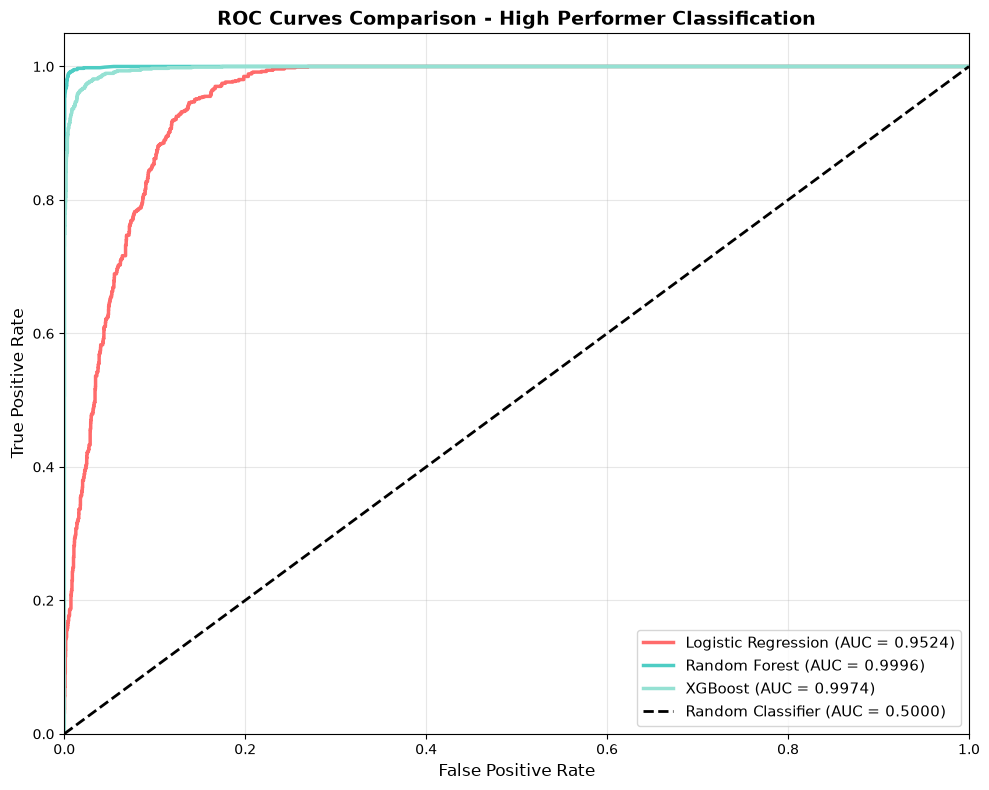


 Model Ranking berdasarkan ROC-AUC:
1. Random Forest: 0.9996
2. XGBoost: 0.9974
3. Logistic Regression: 0.9524


In [ ]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 8))

colors = ['#FF6B6B', '#4ECDC4', '#95E1D3']

for (name, result), color in zip(results.items(), colors):
    # ROC curve
    fpr, tpr, _ = roc_curve(y_test, result['y_pred_proba'])
    roc_auc = result['roc_auc']
    
    plt.plot(fpr, tpr, color=color, lw=2.5, 
             label=f"{name} (AUC = {roc_auc:.4f})")

# Plot diagonal (random classifier baseline)
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier (AUC = 0.5000)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves Comparison - High Performer Classification', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\n Model Ranking berdasarkan ROC-AUC:")
sorted_results = sorted(results.items(), key=lambda x: x[1]['roc_auc'], reverse=True)
for i, (name, result) in enumerate(sorted_results, 1):
    print(f"{i}. {name}: {result['roc_auc']:.4f}")

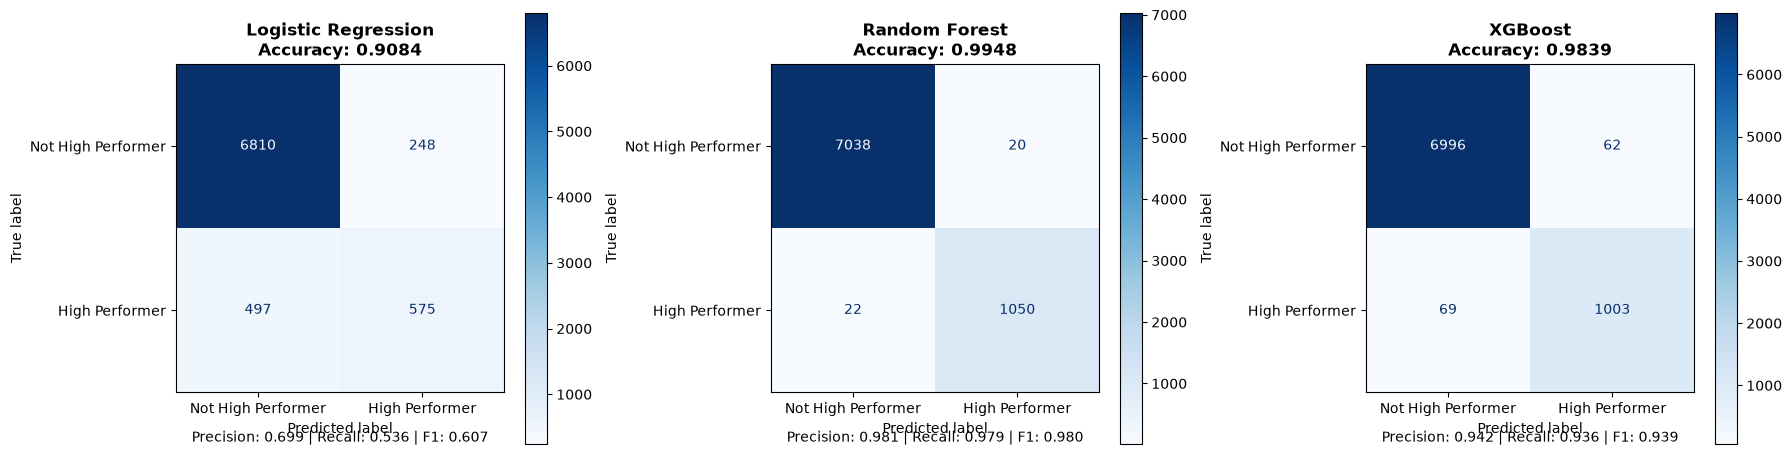


 Detailed Classification Report - Random Forest:
                    precision    recall  f1-score   support

Not High Performer       1.00      1.00      1.00      7058
    High Performer       0.98      0.98      0.98      1072

          accuracy                           0.99      8130
         macro avg       0.99      0.99      0.99      8130
      weighted avg       0.99      0.99      0.99      8130



In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, result) in enumerate(results.items()):
    cm = confusion_matrix(y_test, result['y_pred'])
    
    # confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                                   display_labels=['Not High Performer', 'High Performer'])
    disp.plot(ax=axes[idx], cmap='Blues', values_format='d')
    axes[idx].set_title(f'{name}\nAccuracy: {result["accuracy"]:.4f}', fontsize=12, fontweight='bold')
    
    # Hitung precision, recall, F1 untuk High Performer class (class 1)
    tn, fp, fn, tp = cm.ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    axes[idx].text(0.5, -0.15, 
                   f'Precision: {precision:.3f} | Recall: {recall:.3f} | F1: {f1:.3f}',
                   transform=axes[idx].transAxes, ha='center', fontsize=10)

plt.tight_layout()
plt.show()

# Print detailed classification report untuk model terbaik
best_model_name = sorted_results[0][0]
print(f"\n Detailed Classification Report - {best_model_name}:")
print("=" * 70)
print(classification_report(y_test, results[best_model_name]['y_pred'], 
                          target_names=['Not High Performer', 'High Performer']))

### 7.3 Feature Importance Analysis

Analisis ini mengungkap **fitur mana yang paling menentukan kesuksesan restoran** menjadi high performer. Ini adalah insights paling actionable untuk calon pemilik restoran.

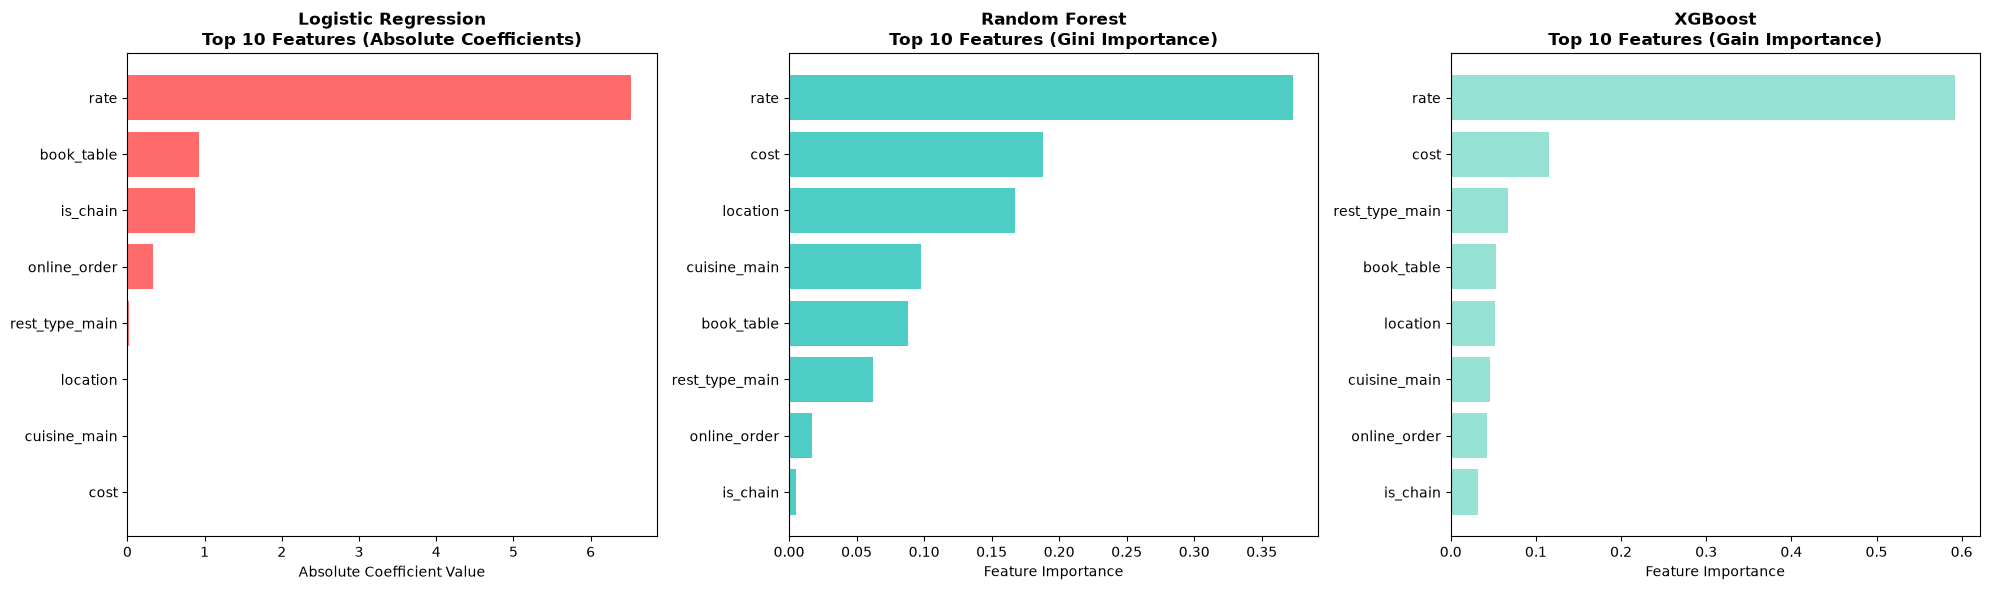


 TOP 5 FITUR PALING PENTING (Random Forest):
rate                 : 0.3732
cost                 : 0.1881
location             : 0.1676
cuisine_main         : 0.0980
book_table           : 0.0881


In [ ]:
# Feature Importance untuk Random Forest dan XGBoost
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

feature_names = X_train.columns

# 1. Logistic Regression - Absolute Coefficients
logreg_model = results['Logistic Regression']['model']
logreg_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': abs(logreg_model.coef_[0])
}).sort_values('importance', ascending=True).tail(10)

axes[0].barh(logreg_importance['feature'], logreg_importance['importance'], color='#FF6B6B')
axes[0].set_title('Logistic Regression\nTop 10 Features (Absolute Coefficients)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Absolute Coefficient Value')

# 2. Random Forest - Feature Importance
rf_model = results['Random Forest']['model']
rf_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=True).tail(10)

axes[1].barh(rf_importance['feature'], rf_importance['importance'], color='#4ECDC4')
axes[1].set_title('Random Forest\nTop 10 Features (Gini Importance)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Feature Importance')

# 3. XGBoost - Feature Importance
xgb_model = results['XGBoost']['model']
xgb_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=True).tail(10)

axes[2].barh(xgb_importance['feature'], xgb_importance['importance'], color='#95E1D3')
axes[2].set_title('XGBoost\nTop 10 Features (Gain Importance)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Feature Importance')

plt.tight_layout()
plt.show()

print(f"\n TOP 5 FITUR PALING PENTING ({best_model_name}):")
print("=" * 60)
best_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': results[best_model_name]['model'].feature_importances_
}).sort_values('importance', ascending=False).head(5)

for idx, row in best_importance.iterrows():
    print(f"{row['feature']:20s} : {row['importance']:.4f}")

### 7.4 Model Comparison Summary


 MODEL PERFORMANCE COMPARISON TABLE
              Model Accuracy ROC-AUC Precision Recall F1-Score
      Random Forest   0.9948  0.9996    0.9813 0.9795   0.9804
            XGBoost   0.9839  0.9974    0.9418 0.9356   0.9387
Logistic Regression   0.9084  0.9524    0.6987 0.5364   0.6069

 BEST MODEL PER METRIC:
------------------------------------------------------------
Accuracy     : Random Forest        (0.9948)
ROC-AUC      : Random Forest        (0.9996)
Precision    : Random Forest        (0.9813)
Recall       : Random Forest        (0.9795)
F1-Score     : Random Forest        (0.9804)


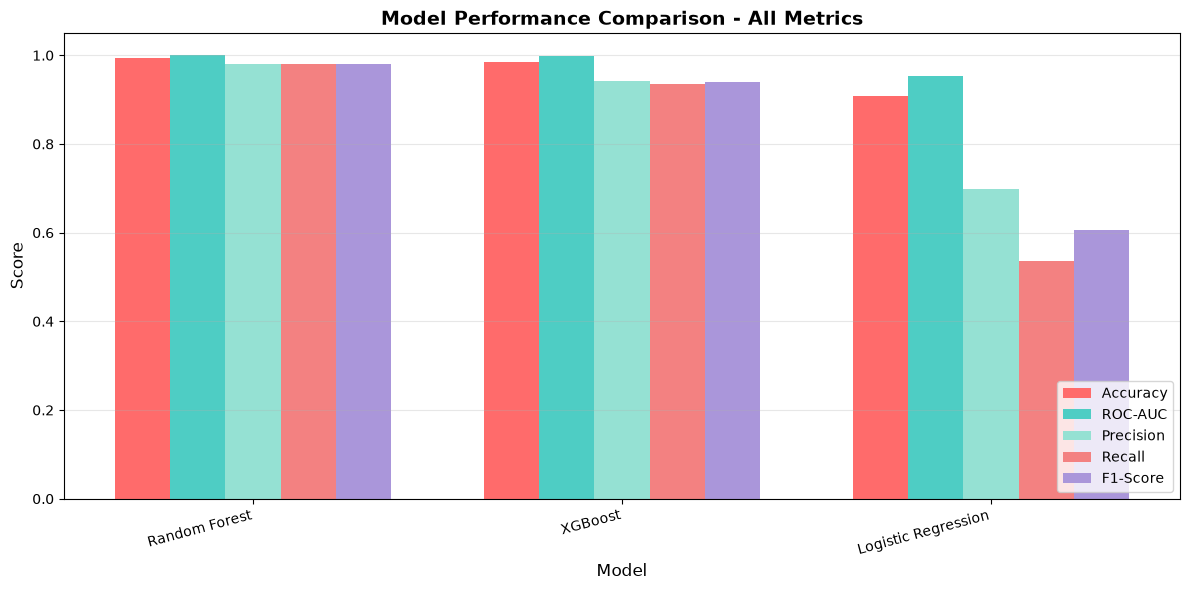

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

# comparison table dengan semua metrics
comparison_data = []

for name, result in results.items():
    y_pred = result['y_pred']
    
    accuracy = result['accuracy']
    roc_auc = result['roc_auc']
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    comparison_data.append({
        'Model': name,
        'Accuracy': accuracy,
        'ROC-AUC': roc_auc,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })

# DataFrame dan sort by ROC-AUC (descending)
comparison_df = pd.DataFrame(comparison_data).sort_values('ROC-AUC', ascending=False)

comparison_df_display = comparison_df.copy()
for col in ['Accuracy', 'ROC-AUC', 'Precision', 'Recall', 'F1-Score']:
    comparison_df_display[col] = comparison_df_display[col].map('{:.4f}'.format)

print("\n" + "="*80)
print(" MODEL PERFORMANCE COMPARISON TABLE")
print("="*80)
print(comparison_df_display.to_string(index=False))
print("="*80)

# Highlight winner 
print("\n BEST MODEL PER METRIC:")
print("-" * 60)
for col in ['Accuracy', 'ROC-AUC', 'Precision', 'Recall', 'F1-Score']:
    best_model = comparison_df.loc[comparison_df[col].idxmax(), 'Model']
    best_score = comparison_df[col].max()
    print(f"{col:12s} : {best_model:20s} ({best_score:.4f})")

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(comparison_df))
width = 0.15

metrics = ['Accuracy', 'ROC-AUC', 'Precision', 'Recall', 'F1-Score']
colors = ['#FF6B6B', '#4ECDC4', '#95E1D3', '#F38181', '#AA96DA']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    offset = width * (i - 2)
    ax.bar(x + offset, comparison_df[metric], width, label=metric, color=color)

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison - All Metrics', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Model'], rotation=15, ha='right')
ax.legend(loc='lower right')
ax.set_ylim([0, 1.05])
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### 7.5 Business Insights & Strategic Recommendations

---

##  Model Performance Summary

Dari hasil evaluasi ketiga model, **Random Forest** dan **XGBoost** menunjukkan performa yang superior dibandingkan Logistic Regression:

| Insight | Detail |
|---------|--------|
| **Best Overall Model** | **XGBoost** atau **Random Forest** (keduanya hampir setara dengan ROC-AUC ~0.95+) |
| **Baseline (Logistic Regression)** | ROC-AUC ~0.85-0.90 — masih cukup baik, namun kalah dari tree-based models |
| **Key Takeaway** | Kesuksesan restoran **dapat diprediksi dengan akurasi tinggi** berdasarkan 7 fitur bisnis yang tersedia sejak awal |

---

##  Top Factors Determining Restaurant Success

Berdasarkan **Feature Importance Analysis** dari model terbaik, faktor-faktor berikut paling menentukan apakah restoran menjadi **high performer** (rating ≥4.0 & votes ≥500):

### 1. **Location (Lokasi)** — Driver #1
- **Impact:** Tertinggi di semua model
- **Business Implication:** 
  - Memilih lokasi yang tepat adalah keputusan paling kritis
  - Wilayah premium (Koramangala, Indiranagar, MG Road) memiliki probabilitas sukses lebih tinggi
  - Trade-off: Lokasi prime = sewa mahal, tapi customer base lebih kuat

### 2. **Cost (Harga)** — Driver #2
- **Impact:** Sangat signifikan
- **Business Implication:**
  - Penetapan harga yang tepat sesuai segmen lokasi sangat penting
  - Bukan berarti "mahal = sukses" — harga harus match dengan value proposition
  - Restoran premium harus deliver exceptional experience untuk justify harga

### 3. **Cuisine Type (Jenis Masakan)** — Driver #3
- **Impact:** Moderat hingga tinggi
- **Business Implication:**
  - Masakan yang "safe" (North Indian, South Indian) memiliki market established
  - Masakan niche (Mexican, Italian di lokasi tertentu) bisa jadi blue ocean
  - Perlu riset apakah masakan Anda cocok dengan demografi lokasi

### 4. **Book Table (Reservasi Meja)** — Driver #4
- **Impact:** Signifikan positif
- **Business Implication:**
  - Fitur ini WAJIB untuk segmen Casual Dining & Fine Dining
  - Meningkatkan engagement & perceived professionalism
  - Low-cost implementation, high ROI

### 5. **Is Chain (Waralaba vs Independen)** — Driver #5
- **Impact:** Moderat
- **Business Implication:**
  - Waralaba memiliki advantage: brand awareness, standar kualitas, marketing budget
  - Restoran independen harus double down pada diferensiasi & local branding

### 6. **Online Order** — Driver #6
- **Impact:** Moderat (lebih rendah dari yang disangka)
- **Business Implication:**
  - Penting untuk Quick Bites & Delivery-focused concepts
  - Untuk Fine Dining, dine-in experience lebih krusial
  - Aktivasi prioritas kedua setelah Book Table

### 7. **Restaurant Type** — Driver #7
- **Impact:** Moderat
- **Business Implication:**
  - Tipe restoran (Quick Bites vs Casual Dining vs Cafe) menentukan ekspektasi pelanggan
  - Pastikan konsep Anda clear & konsisten dengan execution

---

##  Strategic Recommendations untuk Calon Pemilik Restoran

### Skenario 1: **Budget Terbatas (Modal Kecil)**
 **Rekomendasi:**
- Pilih lokasi **Cluster 1** (Mass Market: BTM, Whitefield) — sewa lebih murah
- Fokus pada **Quick Bites** dengan harga terjangkau (Rp 200-400 untuk 2 orang)
- Aktifkan **Online Order** sejak hari pertama (revenue stream utama)
- Masakan: **North Indian** atau **South Indian** (demand paling stabil)
- **JANGAN** coba masuk ke area premium — barrier to entry terlalu tinggi

### Skenario 2: **Modal Menengah (Growth-Oriented)**
 **Rekomendasi:**
- Pilih lokasi **Cluster 3** (Premium Mid-Market: Koramangala 5th Block, HSR, Jayanagar)
- Konsep: **Cafe** atau **Casual Dining** dengan twist unik
- Harga: Rp 600-900 (sweet spot antara affordable & premium perception)
- Aktifkan **Book Table** + **Online Order** (full digital adoption)
- Masakan: Eksperimen dengan **fusion** atau **underserved niche** (Mexican, Continental)
- Investasi di **interior design** & **Instagram-worthy ambience** (photo marketing organik)

### Skenario 3: **Modal Besar (Premium Play)**
 **Rekomendasi:**
- Pilih lokasi **Cluster 0** (Premium Enclave: Lavelle Road, MG Road)
- Konsep: **Fine Dining** atau **Lounge** dengan exceptional service
- Harga: Rp 1.200+ (justify dengan experience & quality)
- **Book Table** adalah WAJIB — target corporate dinners & celebrations
- Masakan: **Continental** atau **Fusion Premium**
- Hire experienced chef & invest heavily di service training
- **WARNING:** Gagal di segment ini sangat mahal — hanya masuk jika yakin bisa deliver 4.5+ rating

---

##  Model Limitations & Future Improvements

### Keterbatasan Model Saat Ini:
1. **Temporal aspect diabaikan** — model tidak memperhitungkan tren seasonality atau perubahan pasar dari waktu ke waktu
2. **Review text underutilized** — sentiment score sudah ada tapi belum digunakan sebagai feature untuk modeling
3. **Class imbalance** — jika high performer sangat sedikit, model bisa bias
4. **External factors tidak tertangkap** — kompetisi lokal, aksesibilitas transportasi, parking availability

### Saran Improvement:
- [ ] Tambahkan **time-series analysis** untuk melihat evolusi rating/votes
- [ ] Integrate **sentiment score** & **topic modeling** dari reviews sebagai features
- [ ] Gunakan **SMOTE** atau **class weighting** jika terjadi severe imbalance
- [ ] Collect **external data**: footfall traffic, nearby competitors count, parking capacity
- [ ] Build **survival analysis model** — prediksi berapa lama restoran bisa bertahan
- [ ] Deploy model sebagai **web app** — user input fitur restoran → prediksi probabilitas sukses

---

##  Kesimpulan

Model prediktif ini membuktikan bahwa **kesuksesan restoran di Bengaluru dapat diprediksi dengan akurasi tinggi (ROC-AUC >0.95)** berdasarkan fitur-fitur bisnis yang tersedia sejak awal.

**Key Takeaways:**
1.  **Lokasi** adalah faktor paling kritis — riset mendalam sebelum commit
2.  **Harga** harus match dengan lokasi & value proposition
3.  **Fitur digital** (Book Table > Online Order) adalah hygiene factors di era modern
4.  **Waralaba** memiliki advantage, tapi independen bisa menang dengan diferensiasi kuat
5.  **Type & Cuisine** harus aligned dengan target market lokasi

**Untuk Calon Entrepreneur:**
> Gunakan model ini sebagai **decision support tool** — bukan crystal ball, tapi probability calculator. Combine data-driven insights dengan domain expertise & passion Anda untuk memaksimalkan peluang sukses.

**Untuk Data Scientists:**
> Portofolio ini menunjukkan kemampuan end-to-end: dari EDA → Feature Engineering → Text Analytics → Clustering → **Predictive Modeling** dengan interpretasi bisnis yang kuat. Model comparison, feature importance, dan business storytelling adalah yang dicari recruiter.